# 电信客户流失预测——逻辑回归模型

## 项目简介
基于电信公司客户数据，构建逻辑回归模型识别影响客户流失的关键因素。
本项目旨在为企业提供科学的客户流失预警和干预依据，提升客户留存率和运营效率

## 核心流程
- 数据准备:加载、清洗、编码
- 特征工程：VIF共线性检验，筛选特征
- 模型训练：原模型（7特征）vs 重建模型（3特征）
- 模型评估：AUC、召回率、精确率、F1
- 阈值优化寻找最佳决策阈值、四档风险分层

## 1.环境准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
images_dir = '../images'

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,confusion_matrix,roc_auc_score,roc_curve,precision_score,recall_score,
    ConfusionMatrixDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif']='SimHei'
plt.rcParams['axes.unicode_minus']=False
pd.set_option('display.unicode.east_asian_width',True)

## 2.数据加载与清洗

In [2]:
# 加载数据并查看基本情况
df = pd.read_csv('customerchurn.csv')
df.info()
df.head()
print(f'数据集清洗前维度：{df.shape}')
print(f'整体流失率:{df['Churn'].mean():.2f} ')

# 删除重复值
df.drop_duplicates(inplace=True)

# 异常值检查
for col in ['MonthlyCharges','tenure']:
    Q1,Q3 = df[col].quantile([0.25,0.75])
    IQR=Q3-Q1
    lower,upper = Q1 - 1.5*IQR,Q3+1.5*IQR
    outliers = df[(df[col]<lower)|(df[col]>upper)]
    print(f"{col}: IQR={IQR:.2f},正常范围=[{lower:.2f},{upper:.2f}],异常值={outliers.shape[0]}个 ")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            7032 non-null   int64  
 1   MonthlyCharges   7032 non-null   float64
 2   SeniorCitizen    7032 non-null   int64  
 3   PaymentMethod    7032 non-null   object 
 4   InternetService  7032 non-null   object 
 5   tenure           7032 non-null   int64  
 6   Contract         7032 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 384.7+ KB
数据集清洗前维度：(7032, 7)
整体流失率:0.27 
MonthlyCharges: IQR=50.40,正常范围=[-35.92,165.67],异常值=0个 
tenure: IQR=47.00,正常范围=[-61.50,126.50],异常值=0个 


## 3.特征工程

### 3.1编码分类变量
付款方式：支付方式---- 电子支票（电子支票）邮寄支票（邮寄支票）银行转账（银行转账）信用卡（信用卡）

使用独热编码处理PaymentMethod，并使用drop_first=True参数让第一个值（Bank transfer，按字母排序的）作为基准值避免多重共线性

使用标签编码处理InternetService，Contract，因为这两列的值之间有联系，使用标签编码大小刚好满足值之间的关系，严谨但也有前提：事先知道哪种会更会导向流失

In [3]:
# 独热编码
pay_dummies = pd.get_dummies(df['PaymentMethod'],prefix='Pay',drop_first=True)
print(f'生成哑变量：{list(pay_dummies.columns)} ')

# 标签编码（与model_service.py保持一致）
INIERNET_MAP = {'No':0,'DSL':1,'Fiber optic':2}
CONTRACT_MAP = {'Month-to-month':0,'One year':1,'Two year':2}
df['InternetService_enc']=df['InternetService'].map(INIERNET_MAP)
df['Contract_enc']=df['Contract'].map(CONTRACT_MAP)

df = pd.concat([df,pay_dummies],axis=1)

生成哑变量：['Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check'] 


### 3.2多重共线性检验（VIF方法）
方差膨胀因子VIF判断标准：

- VIF<5:    normal
- 5<=VIF<=10:moderate
- 10<VIF :   severe

初始特征VIF：


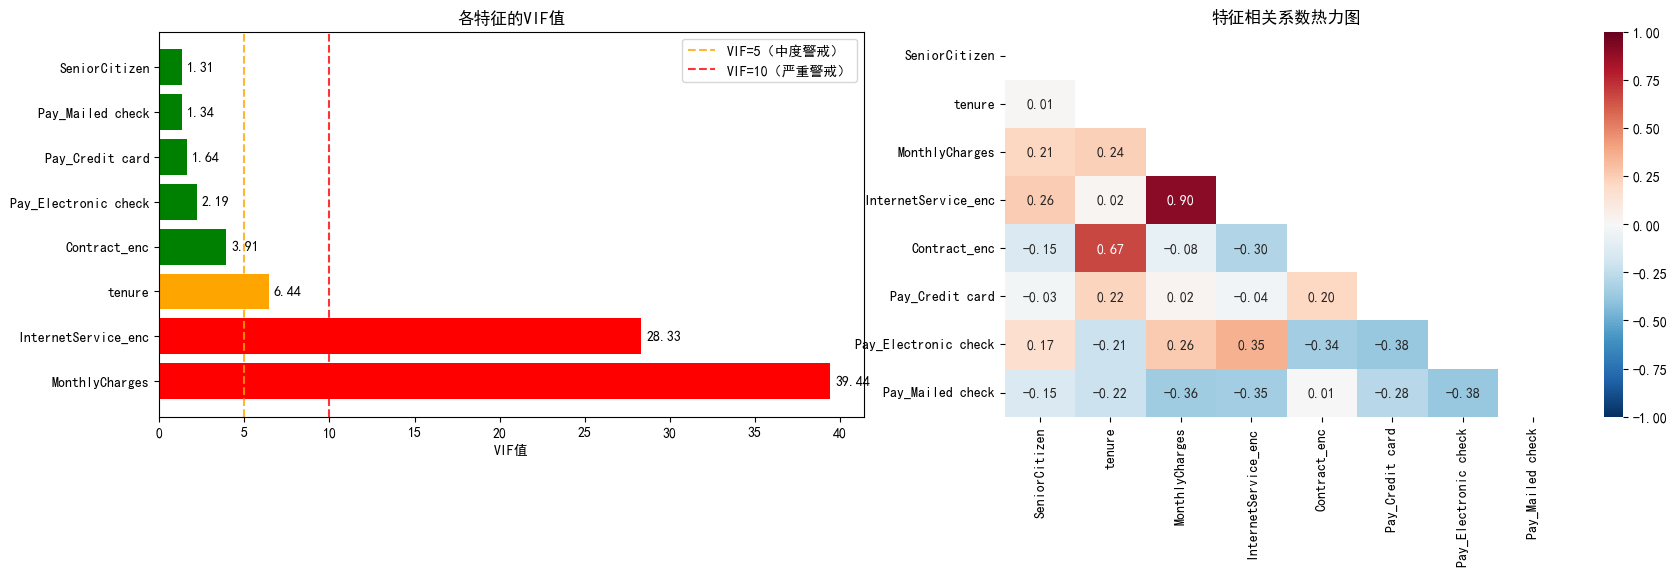

最终特征为7个：['SeniorCitizen', 'tenure', 'InternetService_enc', 'Contract_enc', 'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check'] 


In [4]:
def compute_vif(X):
    vif = pd.DataFrame()
    vif['Feature']=X.columns
    vif['VIF']=[variance_inflation_factor(X.values.astype(float),i) for i in range(X.shape[1])]
    vif['Status']=vif['VIF'].apply(
        lambda v:'Normal' if v<5 else('Moderate' if v<=10 else 'Severe')
    )
    return vif.sort_values('VIF',ascending=False).reset_index(drop=True)

# 初始特征集
initial_features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges',
    'InternetService_enc', 'Contract_enc',
    'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check'
]
X_initial = df[initial_features].astype(float)
vif_result = compute_vif(X_initial)
print('初始特征VIF：')

# 将字段共线性可视化
fig1,ax1 = plt.subplots(1,2,figsize=(20,5))
colors1=['green' if v<5 else 'orange' if v<10 else 'red' for v in vif_result['VIF']]
bars = ax1[0].barh(vif_result['Feature'],vif_result['VIF'],color=colors1)
ax1[0].axvline(x=5,color='orange',linestyle='--',alpha=0.8,label='VIF=5（中度警戒）')
ax1[0].axvline(x=10,color='red',linestyle='--',alpha=0.8,label='VIF=10（严重警戒）')
ax1[0].set_xlabel('VIF值')
ax1[0].set_title('各特征的VIF值')
ax1[0].legend()

for bar,val in zip(bars,vif_result['VIF']):
    ax1[0].text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,
               f'{val:.2f}',va='center',fontsize=10)

corr_=X_initial.corr()
mask = np.triu(np.ones_like(corr_,dtype=bool))
sns.heatmap(corr_,annot=True,fmt='.2f',cmap='RdBu_r',vmax=1,vmin=-1,mask=mask)
ax1[1].set_title('特征相关系数热力图')

# 保存图像
save_vif_path = os.path.join(images_dir,'VIF_and_corr_heatmap.png')
plt.savefig(save_vif_path,dpi=300)
plt.show()

# 删除高共线性特征：MonthlyCharges
# 定义原模型特征
ORIGINAL_FEATURES = [f for f in initial_features if f != 'MonthlyCharges']
print(f'最终特征为7个：{ORIGINAL_FEATURES} ')

## 4.原模型建模（7个特征）

### 4.1使用statsmodels进行统计推断（全样本）

In [5]:
# 全样本的特征和标签
X_orig = df[ORIGINAL_FEATURES].astype(float)
y = df['Churn']


ss = StandardScaler()
X_ss=ss.fit_transform(X_orig)
X_sm=sm.add_constant(X_ss)

logit = sm.Logit(y,X_sm)
result = logit.fit(disp=False)

# 提取统计量
stats = pd.DataFrame({
    'Feature':['const']+ORIGINAL_FEATURES,
    'Coef':   result.params.values,
    'Std_Err':result.bse.values,
    'z_value':result.tvalues.values,
    'p_value':result.pvalues.values,
    'OR':     np.exp(result.params.values),
    '95%_CI_Low':np.exp(result.conf_int()[0]),
    '95%_CI_High':np.exp(result.conf_int()[1])
})
stats.reset_index(drop=True)

McFadden_R_2 = result.prsquared
aic = result.aic
bic = result.bic
print(f'McFadden_R²:{McFadden_R_2:.4f} ')
print(f'AIC:{aic:.4f},    BIC:{bic:.4f} ')

McFadden_R²:0.2614 
AIC:5858.1744,    BIC:5912.8363 


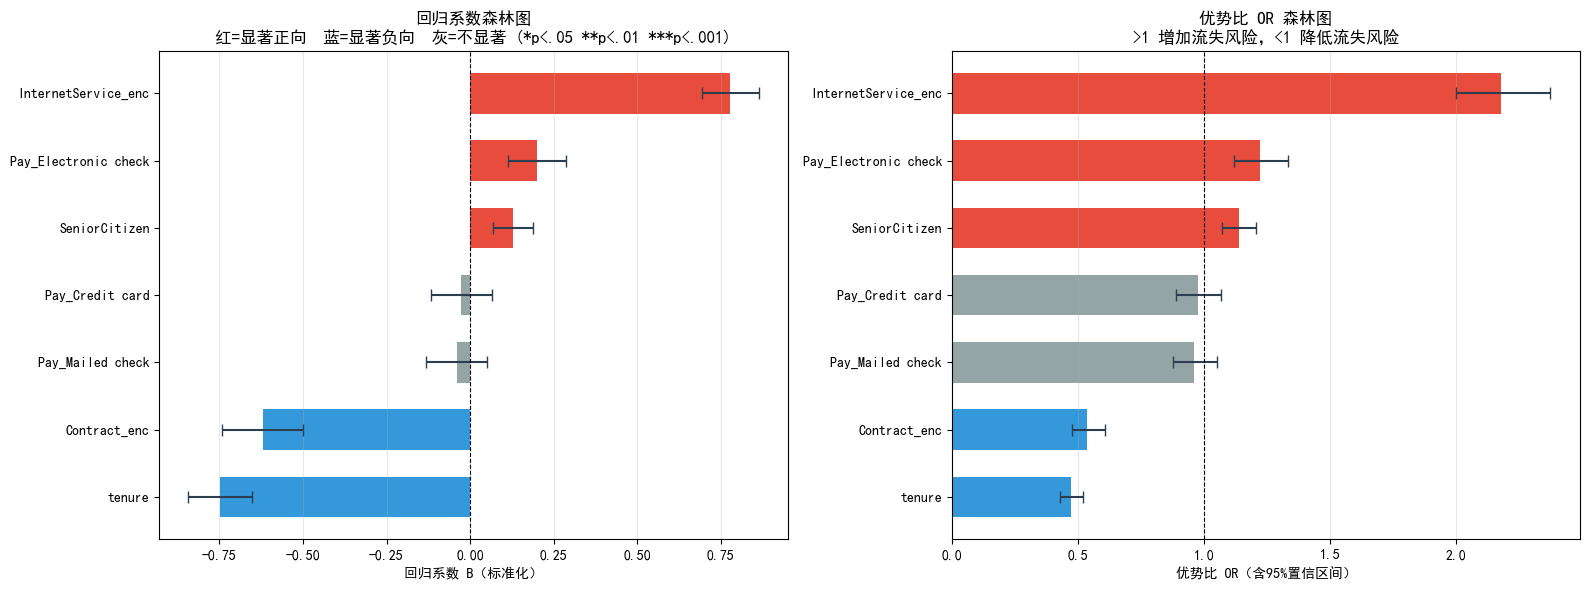

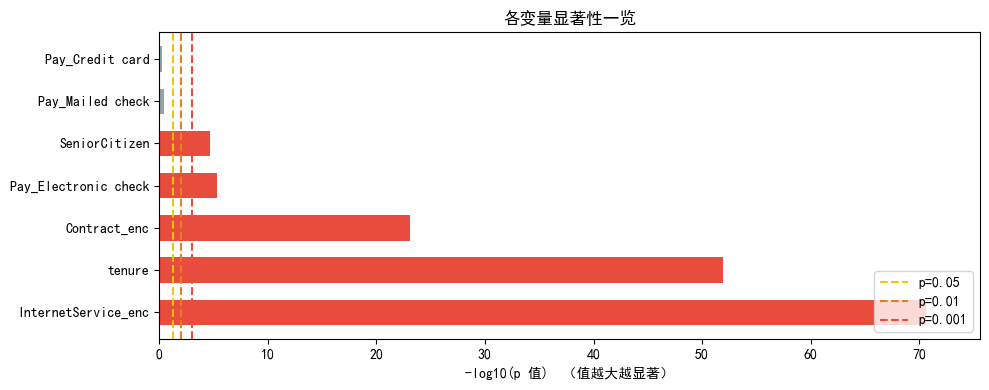

In [6]:
# ========== 4. 模型结果可视化 ==========

# 准备绘图数据
plot_df = stats[stats['Feature'] != 'const'].copy()
plot_df['ci_low_raw']  = result.conf_int().iloc[1:, 0].values
plot_df['ci_high_raw'] = result.conf_int().iloc[1:, 1].values
# 显著性星号标注
plot_df['sig'] = plot_df['p_value']<0.05
plot_df['label'] = plot_df['Feature']

def fc(df, col, th):   # 森林图颜色: 显著正向=红, 显著负向=蓝, 不显著=灰
    conds = [(df['sig']) & (df[col] > th), (df['sig']) & (df[col] <= th)]
    return np.select(conds, ['#e74c3c', '#3498db'], default='#95a5a6')


# ---------- 图1: 系数森林图 + OR森林图 ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 回归系数
df_c = plot_df.sort_values('Coef')
y_c = range(len(df_c))
axes[0].barh(y_c, df_c['Coef'], color=fc(df_c, 'Coef', 0), height=0.6)
axes[0].errorbar(df_c['Coef'], y_c,
                 xerr=[df_c['Coef'] - df_c['ci_low_raw'],
                       df_c['ci_high_raw'] - df_c['Coef']],
                 fmt='none', ecolor='#2c3e50', capsize=4)
axes[0].axvline(0, color='black', ls='--', lw=0.8)
axes[0].set_yticks(y_c)
axes[0].set_yticklabels(df_c['label'], fontsize=10)
axes[0].set_xlabel('回归系数 B（标准化）')
axes[0].set_title('回归系数森林图\n红=显著正向  蓝=显著负向  灰=不显著 (*p<.05 **p<.01 ***p<.001)')
axes[0].grid(axis='x', alpha=0.3)

# 右: 优势比 OR
df_o = plot_df.sort_values('OR')
y_o = range(len(df_o))
axes[1].barh(y_o, df_o['OR'], color=fc(df_o, 'OR', 1), height=0.6)
axes[1].errorbar(df_o['OR'], y_o,
                 xerr=[df_o['OR'] - df_o['95%_CI_Low'],
                       df_o['95%_CI_High'] - df_o['OR']],
                 fmt='none', ecolor='#2c3e50', capsize=4)
axes[1].axvline(1, color='black', ls='--', lw=0.8)
axes[1].set_yticks(y_o)
axes[1].set_yticklabels(df_o['label'], fontsize=10)
axes[1].set_xlabel('优势比 OR（含95%置信区间）')
axes[1].set_title('优势比 OR 森林图\n>1 增加流失风险，<1 降低流失风险')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
save_forest = os.path.join(images_dir,'conf_and_OR.png')
plt.savefig(save_forest,dpi=300)
plt.show()


# ---------- 图2: p值显著性水平 ----------
fig, ax = plt.subplots(figsize=(10, 4))
df_p = plot_df.sort_values('p_value')
logp = -np.log10(df_p['p_value'].clip(lower=1e-300))

p_colors = np.select(
    [df_p['p_value'] < 0.001, df_p['p_value'] < 0.01, df_p['p_value'] < 0.05],
    ['#e74c3c', '#e67e22', '#f1c40f'], default='#95a5a6'
)

bars = ax.barh(df_p['Feature'], logp, color=p_colors, height=0.6)
for p_val, c in [(0.05, '#f1c40f'), (0.01, '#e67e22'), (0.001, '#e74c3c')]:
    ax.axvline(-np.log10(p_val), color=c, ls='--', lw=1.5, label=f'p={p_val}')

ax.set_xlabel('-log10(p 值)  （值越大越显著）')
ax.set_title('各变量显著性一览')
ax.legend(loc='lower right')
ax.set_xlim(0, logp.max() + 5)
plt.tight_layout()
save_p = os.path.join(images_dir,'p_value.png')
plt.savefig(save_p,dpi=300)
plt.show()

### 4.2使用sklearn的LogisticRegression进行预测

In [7]:
# 划分训练/测试集
X_train,X_test,y_train,y_test = train_test_split(X_orig,y,test_size=0.3,random_state=42,stratify=y)

# 构建Pipeline（标准化 + 逻辑回归）
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('clf',LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced'))
])

# 训练模型
pipe.fit(X_train,y_train)
y_prob=pipe.predict_proba(X_test)[:,1]
auc_orig = roc_auc_score(y_test,y_prob)
print(f'训练完成，测试集AUC：{auc_orig:.4f} ')


训练完成，测试集AUC：0.8438 


## 5.原模型评估和交叉验证

原模型默认阈值0.35下的表现结果如下：
accuracy:0.658 
流失类：Precision:0.430,   Recall:0.913,  F1-score:0.585
5折交叉验证结果：
      AUC:0.8349±0.0127   
      Recall:0.8081±0.0250   
      Precision:0.4991±0.0158   
      F1:0.6170±0.0184   


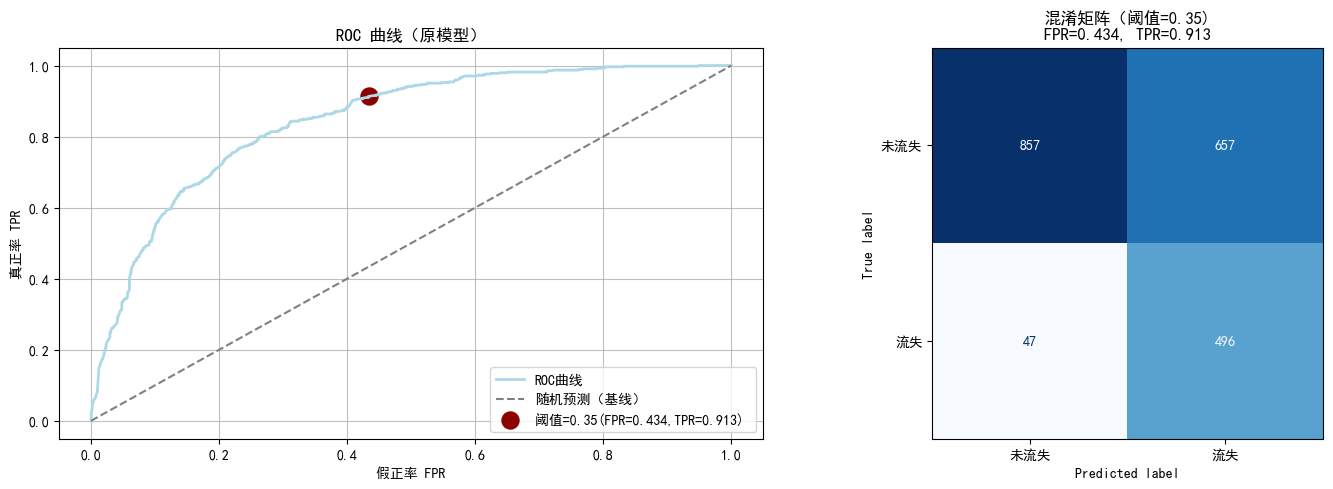

In [8]:
# 默认阈值评估
DEFAULT_THRESHOLD = 0.35
y_pred_default = (y_prob>=DEFAULT_THRESHOLD).astype(int)

report = classification_report(y_test,y_pred_default,target_names=['未流失','流失'],output_dict=True)

accuracy = report['accuracy']
precision = report['流失']['precision']
recall = report['流失']['recall']
f1_score = report['流失']['f1-score']

print('原模型默认阈值0.35下的表现结果如下：')
print(f'accuracy:{accuracy:.3f} ')
print(f'流失类：Precision:{precision:.3f},   Recall:{recall:.3f},  F1-score:{f1_score:.3f}')

# 混淆矩阵
cm = confusion_matrix(y_test,y_pred_default)
tn,fp,fn,tp = cm.ravel()
tpr = tp/(tp+fn) if (tp+fn)>0 else 0
fpr = fp/(fp+tn) if (fp+tn)>0 else 0

# 交叉验证
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_metrics ={
    'AUC':cross_val_score(pipe,X_orig,y,cv=cv,scoring='roc_auc'),
    'Recall':cross_val_score(pipe,X_orig,y,cv=cv,scoring='recall'),
    'Precision':cross_val_score(pipe,X_orig,y,cv=cv,scoring='precision'),
    'F1':cross_val_score(pipe,X_orig,y,cv=cv,scoring='f1')
}

print('5折交叉验证结果：')
for metrics,scores in cv_metrics.items():
    print(f'      {metrics}:{scores.mean():.4f}±{scores.std():.4f}   ')

# ROC曲线 + 混淆矩阵 可视化
fig,ax2=plt.subplots(1,2,figsize=(15,5))

fpr_base,tpr_base,thresholds_roc_base = roc_curve(y_test,y_prob)
# roc_curve遍历所有阈值选择，得到无数个fpr和tpr对应的值。然后可以画ROC曲线
ax2[0].plot(fpr_base,tpr_base,color='lightblue',lw=2,label=f'ROC曲线')
ax2[0].plot([0,1],[0,1],color='gray',ls='--',label='随机预测（基线）')
ax2[0].scatter(
    fpr,tpr,s=150,color='darkred',label=f'阈值={DEFAULT_THRESHOLD}(FPR={fpr:.3f},TPR={tpr:.3f}) '
)
ax2[0].set_xlabel('假正率 FPR')
ax2[0].set_ylabel('真正率 TPR')
ax2[0].set_title('ROC 曲线（原模型）')
ax2[0].legend()
ax2[0].grid(alpha=0.8)

disp_base = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['未流失','流失'])
disp_base.plot(ax=ax2[1],colorbar=False,cmap='Blues')
ax2[1].set_title(f'混淆矩阵（阈值={DEFAULT_THRESHOLD})\nFPR={fpr:.3f}, TPR={tpr:.3f}')

plt.tight_layout()

# 保存图片
save_roc_path = os.path.join(images_dir,'roc_and_matrix.png')
plt.savefig(save_roc_path,dpi=300)
plt.show()

## 6阈值优化与风险分层

最佳F1阈值: 0.60
  Precision: 0.559
  Recall: 0.737
  F1: 0.635


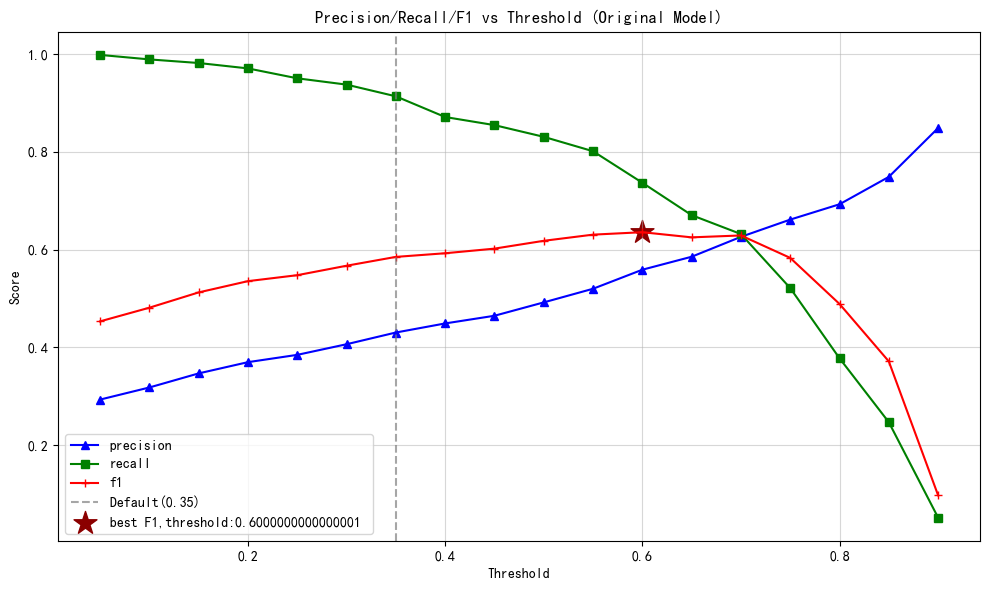

In [9]:
thresholds = np.arange(0.05,0.95,0.05)
metrics_list = []

for thresh in thresholds:
    y_pred =(y_prob>=thresh).astype(int)
    p = precision_score(y_test,y_pred,zero_division=0)
    r = recall_score(y_test,y_pred,zero_division=0)
    f1= 2*p*r/(p+r) if (p+r)>0 else 0.0
    metrics_list.append({'threshold':thresh,'precision':p,'recall':r,'f1':f1})

metrics_df = pd.DataFrame(metrics_list)

# 最佳F1阈值
best_idx = metrics_df['f1'].idxmax()
best_thresh = thresholds[best_idx]

# 可视化
plt.figure(figsize=(10,6))
plt.plot(metrics_df['threshold'],metrics_df['precision'],'blue',marker='^',label='precision')
plt.plot(metrics_df['threshold'],metrics_df['recall'],'green',marker='s',label='recall')
plt.plot(metrics_df['threshold'],metrics_df['f1'],'red',marker='+',label='f1')
plt.axvline(x=DEFAULT_THRESHOLD,color='gray',linestyle='--',alpha=0.7,label=f'Default({DEFAULT_THRESHOLD}) ')

plt.scatter(best_thresh,metrics_df.loc[best_idx,'f1'],s=300,marker='*'
            ,c='darkred',label=f'best F1,threshold:{best_thresh} ')

plt.grid(alpha=0.5)
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Original Model)')
plt.tight_layout()

print(f"最佳F1阈值: {best_thresh:.2f}")
print(f"  Precision: {metrics_df.loc[best_idx, 'precision']:.3f}")
print(f"  Recall: {metrics_df.loc[best_idx, 'recall']:.3f}")
print(f"  F1: {metrics_df.loc[best_idx, 'f1']:.3f}")

# 保存图片
save_original = os.path.join(images_dir,'Original_model_score.png')
plt.savefig(save_original,dpi=300)
plt.show()

In [10]:
# 风险四档分层（基于三个锚点）
RECALL_TARGET =0.9
PRECISION_TARGET = 0.6

# 找到3个关键阈值
precision_60_thresh = metrics_df[metrics_df['precision']>=PRECISION_TARGET]['threshold'].min()
recall_90_thresh = metrics_df[metrics_df['recall']>=RECALL_TARGET]['threshold'].max()

# 排序得到分层边界
anchor_points = sorted([recall_90_thresh,best_thresh,precision_60_thresh])
low_cut,mid_cut,high_cut = anchor_points
print("四档风险分层:")
print(f"  低风险:     P < {low_cut:.2f}  (Recall≥{RECALL_TARGET:.0%}锚点)")
print(f"  中等风险:   {low_cut:.2f} ≤ P < {mid_cut:.2f}  (F1最优锚点)")
print(f"  较高风险:   {mid_cut:.2f} ≤ P < {high_cut:.2f}  (Precision≥{PRECISION_TARGET:.0%}锚点)")
print(f"  高风险:     P ≥ {high_cut:.2f}")

# 测试集分布
risk_levels = pd.cut(y_prob,bins=[-np.inf,low_cut,mid_cut,high_cut,np.inf],
                    labels=['低风险','中等风险','较高风险','高风险'])
risk_levels.value_counts().sort_index()

四档风险分层:
  低风险:     P < 0.35  (Recall≥90%锚点)
  中等风险:   0.35 ≤ P < 0.60  (F1最优锚点)
  较高风险:   0.60 ≤ P < 0.70  (Precision≥60%锚点)
  高风险:     P ≥ 0.70


低风险      904
中等风险    437
较高风险    168
高风险      548
Name: count, dtype: int64

## 7.重建模型（3个特征）+ 模型评估


重建模型完成：
特征：['tenure', 'InternetService_enc', 'Is_Electronic_check'] 
测试集AUC：0.8345 
重建模型默认阈值0.35下的表现： 
accuracy:0.654 
流失类：Precision:0.426,    Recall:0.884,   F1-score:0.575 
最佳F1阈值: 0.55
  Precision: 0.532
  Recall: 0.755
  F1: 0.624


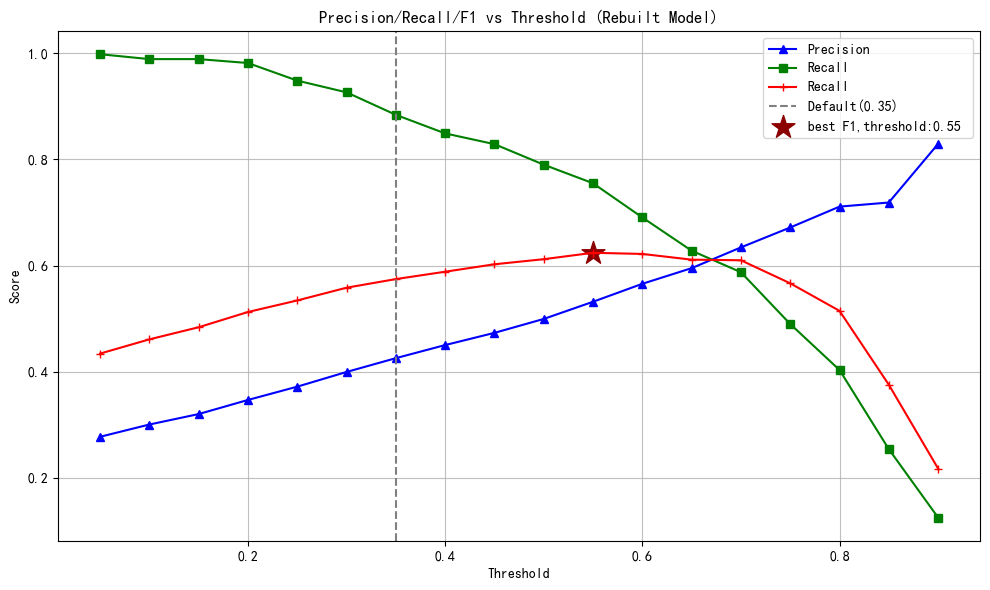

In [11]:
# 重建模型特征（与model_service.py对齐）
REBUILT_FEATURES = ['tenure', 'InternetService_enc', 'Is_Electronic_check']
# 其实这里用REBUILT_FEATURES = ['tenure', 'InternetService_enc', 'Contract_enc']也可以。

# 从原特征构造重建模型
X_rebuilt = pd.DataFrame({
    'tenure':df['tenure'].astype(float),
    'InternetService_enc':df['InternetService_enc'].astype(float),
    'Is_Electronic_check':(df['PaymentMethod']=='Electronic check').astype(float)
})

# 划分训练/测试集 + 训练模型
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rebuilt,y,test_size=0.3,random_state=42,stratify=y
)
pipe_r = Pipeline([
    ('scaler',StandardScaler()),
    ('clf',LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced'))
])
pipe_r.fit(X_train_r,y_train_r)
y_prob_r = pipe_r.predict_proba(X_test_r)[:,1]
print("重建模型完成：")
print(f'特征：{REBUILT_FEATURES} ')
auc_rebuilt = roc_auc_score(y_test_r,y_prob_r)
print(f'测试集AUC：{auc_rebuilt:.4f} ')

y_pred_r_default = (y_prob_r>=DEFAULT_THRESHOLD).astype(int)
report_r = classification_report(y_test_r,y_pred_r_default,target_names=['未流失','流失'],output_dict=True)

accuracy_r = report_r['accuracy']
precision_r = report_r['流失']['precision']
recall_r = report_r['流失']['recall']
f1_score_r = report_r['流失']['f1-score']

print('重建模型默认阈值0.35下的表现： ')
print(f'accuracy:{accuracy_r:.3f} ')
print(f'流失类：Precision:{precision_r:.3f},    Recall:{recall_r:.3f},   F1-score:{f1_score_r:.3f} ')


# 阈值优化可视化
metrics_list_r = []
for thresh in thresholds:
    y_pred = (y_prob_r>=thresh).astype(int)
    p = precision_score(y_test_r,y_pred,zero_division=0)
    r = recall_score(y_test_r,y_pred,zero_division=0)
    f1= 2*p*r/(p+r) if (p+r)>0 else 0
    metrics_list_r.append({'threshold':thresh,'precision':p,'recall':r,'f1':f1})

metrics_df_r = pd.DataFrame(metrics_list_r)

best_idx_r = metrics_df_r['f1'].idxmax()
best_thresh_r=thresholds[best_idx_r]

plt.figure(figsize=(10,6))
plt.plot(metrics_df_r['threshold'],metrics_df_r['precision'],'b-^',label='Precision')
plt.plot(metrics_df_r['threshold'],metrics_df_r['recall'],'g-s',label='Recall')
plt.plot(metrics_df_r['threshold'],metrics_df_r['f1'],'r-+',label='Recall')
plt.axvline(x=DEFAULT_THRESHOLD,color='gray',linestyle='--',label=f'Default({DEFAULT_THRESHOLD}) ')
plt.scatter(best_thresh_r,metrics_df_r.loc[best_idx_r,'f1'],color='darkred',marker='*'
            ,s=300,label=f'best F1,threshold:{best_thresh_r} ')

plt.legend()
plt.grid(alpha=0.8)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Rebuilt Model)')
plt.tight_layout()

print(f"最佳F1阈值: {best_thresh_r:.2f}")
print(f"  Precision: {metrics_df_r.loc[best_idx_r, 'precision']:.3f}")
print(f"  Recall: {metrics_df_r.loc[best_idx_r, 'recall']:.3f}")
print(f"  F1: {metrics_df_r.loc[best_idx_r, 'f1']:.3f}")

# 保存图片
save_rebuilt = os.path.join(images_dir,'Rebuilt_model_score.png')
plt.savefig(save_rebuilt,dpi=300)
plt.show()

## 8.模型对比与结论

In [12]:
# 汇总对比
comparison = pd.DataFrame({
    '指标':['AUC','Accuracy','Precision','Recall','F1'],
    '原模型（7特征）':[
        roc_auc_score(y_test,y_prob),
        accuracy,
        precision,
        recall,
        f1_score
    ],
    '重建模型（3特征）':[
        roc_auc_score(y_test,y_prob_r),
        accuracy_r,
        precision_r,
        recall_r,
        f1_score_r
    ]    
})
display(comparison)
print('最佳阈值对比：')
print(f'原模型：{best_thresh:.2f}(f1:{metrics_df.loc[best_idx,'f1']:.4f}) ')
print(f'重建模型：{best_thresh_r:.2f}(f1:{metrics_df_r.loc[best_idx_r,'f1']:.4f}) ')


,指标,原模型（7特征）,重建模型（3特征）
0,AUC,0.843831,0.834530
1,Accuracy,0.657754,0.654351
2,Precision,0.430182,0.425532
3,Recall,0.913444,0.883978
4,F1,0.584906,0.574506


最佳阈值对比：
原模型：0.60(f1:0.6354) 
重建模型：0.55(f1:0.6240) 
